<a href="https://colab.research.google.com/github/mikakia/FL_VIP/blob/main/knee_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
cd FL-VIP/

[Errno 2] No such file or directory: 'FL-VIP/'
/content


# Load data

In [4]:
folder_dir = '/content/drive/MyDrive/FL-VIP/knee_images'

In [5]:
print("Exists:", os.path.exists(folder_dir))
print("folder_dir =", folder_dir)

Exists: True
folder_dir = /content/drive/MyDrive/FL-VIP/knee_images


In [6]:
knee_images = datasets.ImageFolder(root=folder_dir, transform=transforms.ToTensor())
print(type(knee_images[0]))

<class 'tuple'>


# Explore Data

In [7]:
print(f"Classes:{knee_images.classes}")
print(f"Class and Index: {knee_images.class_to_idx}")
print(f"Total images: {len(knee_images)}")

Classes:['0', '1', '2', '3', '4']
Class and Index: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
Total images: 7010


In [8]:
counts = Counter(knee_images.targets)
for class_idx, count in sorted(counts.items()):
    print(f"Class {knee_images.classes[class_idx]}: {count} images")

Class 0: 2921 images
Class 1: 1342 images
Class 2: 1516 images
Class 3: 980 images
Class 4: 251 images


In [9]:
image, label = knee_images[0]
print(image.shape)
print(label)

torch.Size([3, 224, 224])
0


In [28]:
shapes = {}

for image, label in knee_images:
    shape = tuple(image.shape)
    #print(shape)
    if shape not in shapes:
        shapes[shape] = 0
        print('New Shape alallala')
    shapes[shape] = shapes[shape]+1

for shape, count in shapes.items():
    print(f"Shape{shape}: {count} images")

New Shape alallala
Shape(3, 224, 224): 7010 images


## Plot of count of images per class

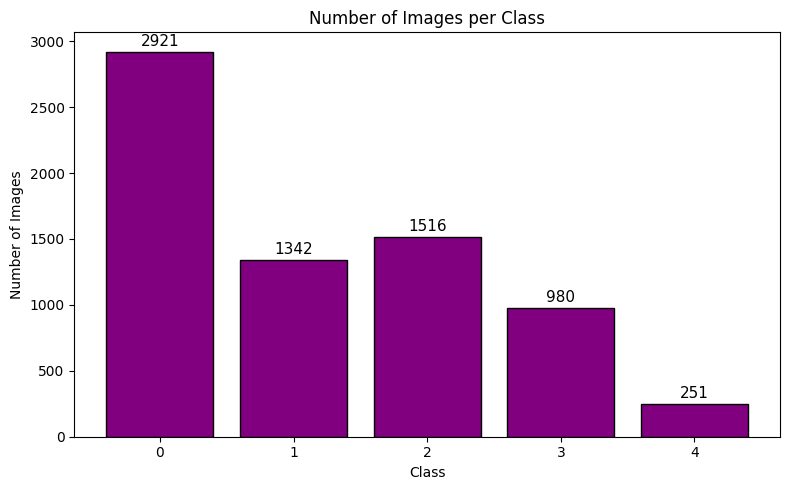

In [12]:
class_names = knee_images.classes
values = [counts[i] for i in range(len(class_names))]


plt.figure(figsize=(8, 5))
bars = plt.bar(class_names, values, color='purple', edgecolor='black')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             str(val), ha='center', va='bottom', fontsize=11)

plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

## Plot of an example image from each class

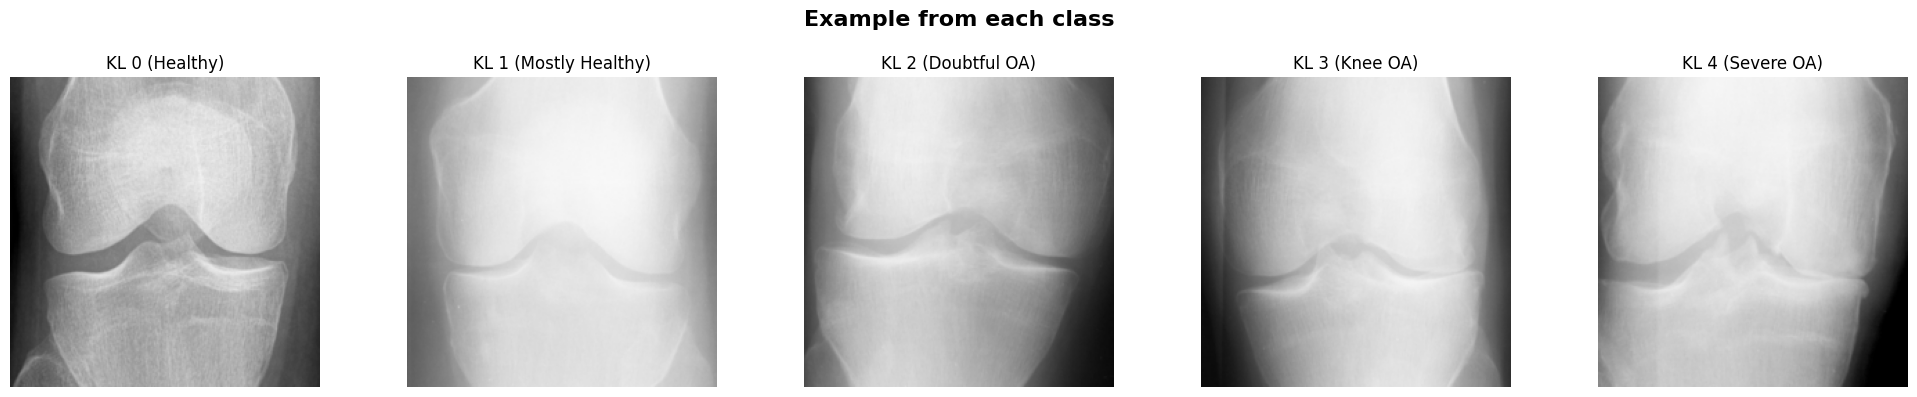

In [25]:
class_labels = {
    0: 'KL 0 (Healthy)',
    1: 'KL 1 (Mostly Healthy)',
    2: 'KL 2 (Doubtful OA)',
    3: 'KL 3 (Knee OA)',
    4: 'KL 4 (Severe OA)'
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for class_idx in range(len(knee_images.classes)):
    idx = knee_images.targets.index(class_idx)
    img, label = knee_images[idx]

    axes[class_idx].imshow(img.permute(1, 2, 0))
    axes[class_idx].set_title(f'{class_labels[class_idx]}')
    axes[class_idx].axis('off')

plt.suptitle('Example from each class\n', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()